<a href="https://colab.research.google.com/github/JenanJn/Elbow-fracture-segmentation/blob/main/healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving elbow_positive_dataset.zip to elbow_positive_dataset.zip


In [ ]:
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/elbow_positive_dataset.zip")
DATASET_DIR = Path("/content/elbow_positive_dataset")

# Extract
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("Dataset extracted successfully!")

# Show the top-level structure
for item in DATASET_DIR.iterdir():
    print(item)

Dataset extracted successfully!
/content/elbow_positive_dataset/elbow_dataset


In [ ]:
import json
from pathlib import Path

DATASET_DIR = Path("/content/elbow_positive_dataset/elbow_dataset")

for split in ["train", "valid", "test"]:
    annotation_file = DATASET_DIR / split / "_annotations.coco.json"

    with open(annotation_file, "r") as f:
        coco = json.load(f)

    print(f"\n{split.upper()}")
    print("Images      :", len(coco["images"]))
    print("Annotations :", len(coco["annotations"]))
    print("Classes     :", [c["name"] for c in coco["categories"]])


TRAIN
Images      : 425
Annotations : 469
Classes     : ['elbow positive']

VALID
Images      : 131
Annotations : 144
Classes     : ['elbow positive']

TEST
Images      : 62
Annotations : 68
Classes     : ['elbow positive']


In [ ]:
import json
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np

DATASET_DIR = Path("/content/elbow_positive_dataset/elbow_dataset")
MASK_ROOT = Path("/content/elbow_positive_dataset/masks")

def create_mask(width, height, annotations):
    mask = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask)

    for ann in annotations:
        segmentation = ann.get("segmentation", [])

        # COCO polygon segmentation
        if isinstance(segmentation, list):
            for polygon in segmentation:
                if len(polygon) >= 6:
                    points = [
                        (polygon[i], polygon[i + 1])
                        for i in range(0, len(polygon) - 1, 2)
                    ]
                    draw.polygon(points, fill=255)

    return mask


for split in ["train", "valid", "test"]:

    annotation_file = DATASET_DIR / split / "_annotations.coco.json"

    with open(annotation_file, "r") as f:
        coco = json.load(f)

    output_dir = MASK_ROOT / split
    output_dir.mkdir(parents=True, exist_ok=True)

    # Map image ID → image information
    images = {img["id"]: img for img in coco["images"]}

    # Map image ID → annotations
    annotations_by_image = {}

    for ann in coco["annotations"]:
        annotations_by_image.setdefault(
            ann["image_id"], []
        ).append(ann)

    mask_count = 0

    for image_id, image_info in images.items():

        width = image_info["width"]
        height = image_info["height"]

        annotations = annotations_by_image.get(image_id, [])

        mask = create_mask(
            width,
            height,
            annotations
        )

        image_name = Path(
            image_info["file_name"]
        ).stem

        mask_path = output_dir / f"{image_name}.png"

        mask.save(mask_path)

        mask_count += 1

    print(
        f"{split.upper()}: "
        f"{mask_count} masks created"
    )

print("\n✅ ALL SEGMENTATION MASKS CREATED")
print("Mask location:", MASK_ROOT)

TRAIN: 425 masks created
VALID: 131 masks created
TEST: 62 masks created

✅ ALL SEGMENTATION MASKS CREATED
Mask location: /content/elbow_positive_dataset/masks


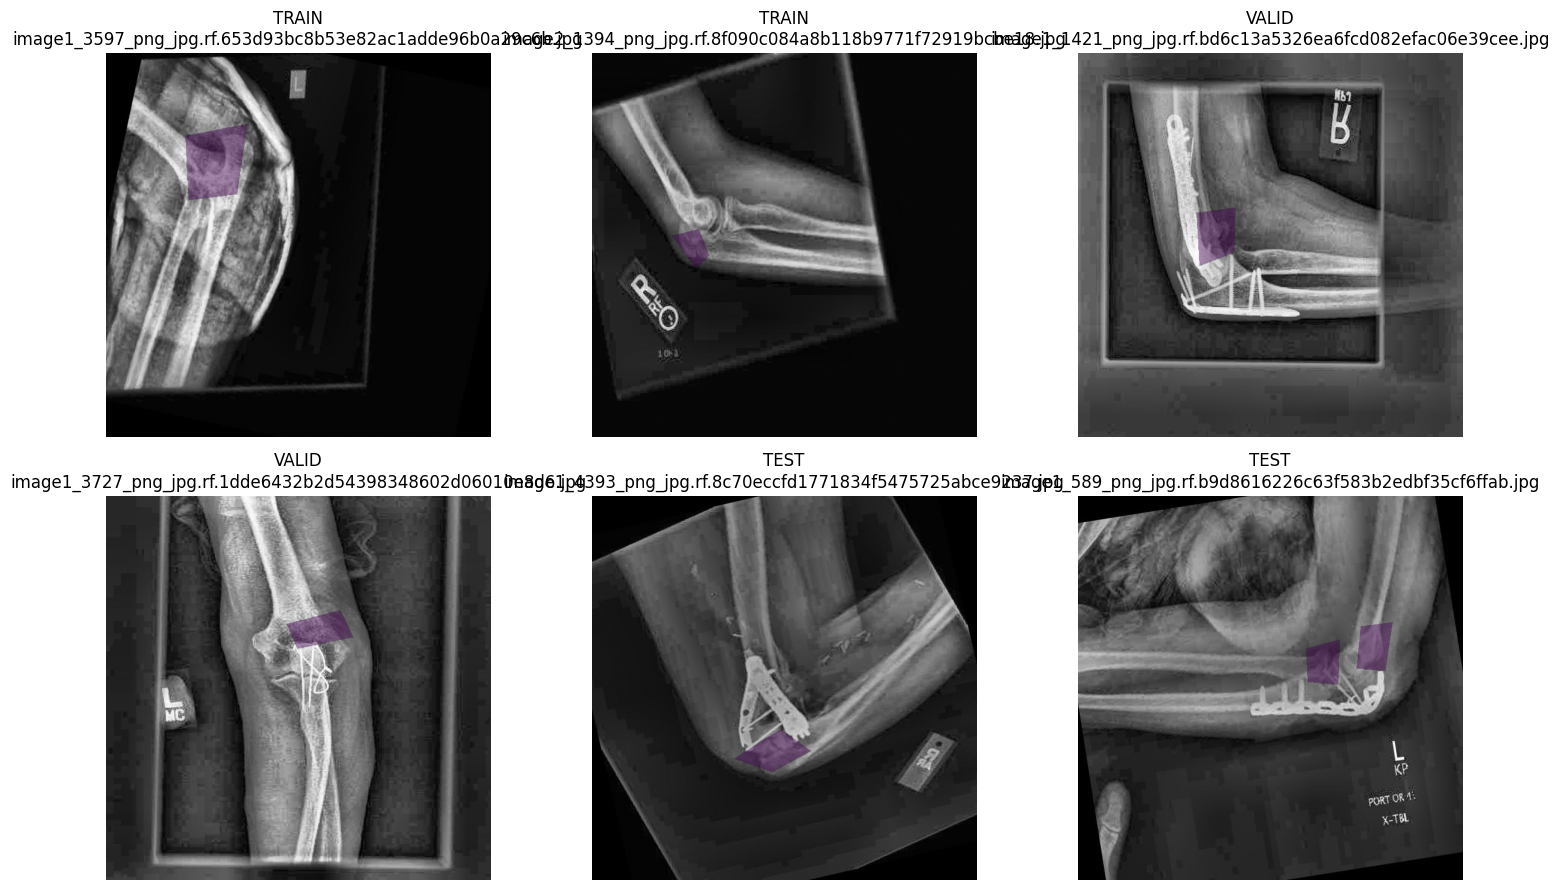

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, split in zip(
    axes.flatten(),
    ["train", "train", "valid", "valid", "test", "test"]
):

    image_dir = DATASET_DIR / split
    mask_dir = MASK_ROOT / split

    image_files = [
        f for f in image_dir.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    image_path = random.choice(image_files)
    mask_path = mask_dir / f"{image_path.stem}.png"

    image = np.array(
        Image.open(image_path).convert("L")
    )

    mask = np.array(
        Image.open(mask_path)
    )

    ax.imshow(image, cmap="gray")

    # Overlay mask
    ax.imshow(
        np.ma.masked_where(
            mask == 0,
            mask
        ),
        alpha=0.45
    )

    ax.set_title(
        f"{split.upper()}\n{image_path.name}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

print("segmentation_models_pytorch:", smp.__version__)

segmentation_models_pytorch: 0.5.0


In [ ]:
import torch
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

model = model.to(DEVICE)

print("Device:", DEVICE)
print("Model: U-Net")
print("Encoder: ResNet34")
print("Pretrained weights: ImageNet")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Device: cuda
Model: U-Net
Encoder: ResNet34
Pretrained weights: ImageNet


In [ ]:
import numpy as np
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

DATASET_DIR = Path("/content/elbow_positive_dataset/elbow_dataset")
MASK_ROOT = Path("/content/elbow_positive_dataset/masks")

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 8


class ElbowSegmentationDataset(Dataset):

    def __init__(self, split):

        self.image_dir = DATASET_DIR / split
        self.mask_dir = MASK_ROOT / split

        self.samples = []

        for image_path in sorted(self.image_dir.iterdir()):

            if image_path.suffix.lower() in [
                ".jpg", ".jpeg", ".png", ".bmp"
            ]:

                mask_path = (
                    self.mask_dir /
                    f"{image_path.stem}.png"
                )

                if mask_path.exists():
                    self.samples.append(
                        (image_path, mask_path)
                    )

        if len(self.samples) == 0:
            raise RuntimeError(
                f"No image-mask pairs found for {split}"
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image_path, mask_path = self.samples[idx]

        # Load X-ray
        image = Image.open(
            image_path
        ).convert("L")

        # Load segmentation mask
        mask = Image.open(
            mask_path
        ).convert("L")

        # Resize
        image = image.resize(
            IMAGE_SIZE,
            Image.Resampling.BILINEAR
        )

        mask = mask.resize(
            IMAGE_SIZE,
            Image.Resampling.NEAREST
        )

        # Convert to numpy
        image = np.asarray(
            image,
            dtype=np.float32
        ) / 255.0

        mask = np.asarray(
            mask,
            dtype=np.float32
        )

        # Binary mask
        mask = (mask > 127).astype(
            np.float32
        )

        # Convert grayscale → 3 channels
        image = np.stack(
            [image, image, image],
            axis=0
        )

        # ImageNet normalization
        mean = np.array(
            [0.485, 0.456, 0.406],
            dtype=np.float32
        )[:, None, None]

        std = np.array(
            [0.229, 0.224, 0.225],
            dtype=np.float32
        )[:, None, None]

        image = (
            image - mean
        ) / std

        # Add mask channel
        mask = mask[None, :, :]

        return (
            torch.tensor(
                image,
                dtype=torch.float32
            ),
            torch.tensor(
                mask,
                dtype=torch.float32
            )
        )


# Create datasets
train_dataset = ElbowSegmentationDataset("train")
valid_dataset = ElbowSegmentationDataset("valid")
test_dataset = ElbowSegmentationDataset("test")


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("Training images   :", len(train_dataset))
print("Validation images :", len(valid_dataset))
print("Testing images    :", len(test_dataset))

Training images   : 425
Validation images : 131
Testing images    : 62


In [ ]:
images, masks = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Mask batch shape  :", masks.shape)
print("Image device      :", images.device)
print("Mask values       :", torch.unique(masks))

Image batch shape : torch.Size([8, 3, 256, 256])
Mask batch shape  : torch.Size([8, 1, 256, 256])
Image device      : cpu
Mask values       : tensor([0., 1.])


In [ ]:
import torch
import torch.nn as nn


def dice_loss(logits, targets, smooth=1.0):
    """
    Dice loss for binary segmentation.
    """
    probabilities = torch.sigmoid(logits)

    probabilities = probabilities.flatten(1)
    targets = targets.flatten(1)

    intersection = (probabilities * targets).sum(dim=1)

    dice = (
        (2 * intersection + smooth)
        /
        (probabilities.sum(dim=1) +
         targets.sum(dim=1) +
         smooth)
    )

    return 1 - dice.mean()


def combined_loss(logits, targets):
    """
    BCE + Dice loss.
    """

    bce = nn.functional.binary_cross_entropy_with_logits(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return 0.5 * bce + 0.5 * dice


@torch.no_grad()
def calculate_metrics(logits, targets, threshold=0.5):

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (
        predictions * targets
    ).sum(dim=1)

    # Dice
    dice = (
        (2 * intersection + 1e-6)
        /
        (
            predictions.sum(dim=1)
            + targets.sum(dim=1)
            + 1e-6
        )
    )

    # IoU
    union = (
        predictions.sum(dim=1)
        + targets.sum(dim=1)
        - intersection
    )

    iou = (
        (intersection + 1e-6)
        /
        (union + 1e-6)
    )

    return dice.mean().item(), iou.mean().item()


print("Loss and evaluation functions created successfully.")
print("Loss  : BCE + Dice")
print("Metric: Dice coefficient")
print("Metric: IoU")

Loss and evaluation functions created successfully.
Loss  : BCE + Dice
Metric: Dice coefficient
Metric: IoU


In [ ]:
# Get one batch
images, masks = next(iter(train_loader))

# Move to GPU
images = images.to(DEVICE)
masks = masks.to(DEVICE)

# Forward pass
with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Output shape:", outputs.shape)
print("GPU        :", images.device)

Input shape : torch.Size([8, 3, 256, 256])
Mask shape  : torch.Size([8, 1, 256, 256])
Output shape: torch.Size([8, 1, 256, 256])
GPU        : cuda:0


In [ ]:
import time
import torch

EPOCHS = 10
LEARNING_RATE = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)


def run_epoch(model, loader, optimizer=None):

    # Training mode if optimizer is provided
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0
    total_dice = 0
    total_iou = 0

    for images, masks in loader:

        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_training):

            outputs = model(images)

            loss = combined_loss(
                outputs,
                masks
            )

            if is_training:

                optimizer.zero_grad()

                loss.backward()

                optimizer.step()

        dice, iou = calculate_metrics(
            outputs,
            masks
        )

        total_loss += loss.item()
        total_dice += dice
        total_iou += iou

    n = len(loader)

    return (
        total_loss / n,
        total_dice / n,
        total_iou / n
    )


best_val_dice = 0

history = []


for epoch in range(1, EPOCHS + 1):

    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------

    train_loss, train_dice, train_iou = run_epoch(
        model,
        train_loader,
        optimizer
    )

    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_dice, val_iou = run_epoch(
        model,
        valid_loader
    )

    epoch_time = time.time() - start_time

    print(
        f"\nEpoch {epoch}/{EPOCHS}"
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Train Dice : {train_dice:.4f}"
    )

    print(
        f"Train IoU  : {train_iou:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Dice   : {val_dice:.4f}"
    )

    print(
        f"Val IoU    : {val_iou:.4f}"
    )

    print(
        f"Time       : {epoch_time:.1f} seconds"
    )

    # Save history

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_dice": train_dice,
        "train_iou": train_iou,
        "val_loss": val_loss,
        "val_dice": val_dice,
        "val_iou": val_iou
    })

    # -------------------------
    # Save best model
    # -------------------------

    if val_dice > best_val_dice:

        best_val_dice = val_dice

        torch.save(
            model.state_dict(),
            "/content/best_elbow_fracture_unet.pth"
        )

        print(
            "⭐ Best model saved!"
        )


print("\n==============================")
print("TRAINING COMPLETE")
print("==============================")

print(
    f"Best Validation Dice: "
    f"{best_val_dice:.4f}"
)


Epoch 1/10
Train Loss : 0.7788
Train Dice : 0.1037
Train IoU  : 0.0572
Val Loss   : 0.7394
Val Dice   : 0.1225
Val IoU    : 0.0681
Time       : 8.2 seconds
⭐ Best model saved!

Epoch 2/10
Train Loss : 0.6625
Train Dice : 0.2760
Train IoU  : 0.1757
Val Loss   : 0.6423
Val Dice   : 0.2401
Val IoU    : 0.1556
Time       : 7.7 seconds
⭐ Best model saved!

Epoch 3/10
Train Loss : 0.5936
Train Dice : 0.3706
Train IoU  : 0.2587
Val Loss   : 0.5803
Val Dice   : 0.3284
Val IoU    : 0.2265
Time       : 8.2 seconds
⭐ Best model saved!

Epoch 4/10
Train Loss : 0.5393
Train Dice : 0.4705
Train IoU  : 0.3384
Val Loss   : 0.5254
Val Dice   : 0.4282
Val IoU    : 0.3174
Time       : 7.8 seconds
⭐ Best model saved!

Epoch 5/10
Train Loss : 0.4940
Train Dice : 0.5493
Train IoU  : 0.4047
Val Loss   : 0.4896
Val Dice   : 0.4999
Val IoU    : 0.3710
Time       : 8.2 seconds
⭐ Best model saved!

Epoch 6/10
Train Loss : 0.4566
Train Dice : 0.6006
Train IoU  : 0.4543
Val Loss   : 0.4657
Val Dice   : 0.4959
Val

In [ ]:
model.load_state_dict(
    torch.load(
        "/content/best_elbow_fracture_unet.pth",
        map_location=DEVICE
    )
)

model = model.to(DEVICE)

test_loss, test_dice, test_iou = run_epoch(
    model,
    test_loader
)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")


FINAL TEST RESULTS
Test Loss : 0.3204
Test Dice : 0.6829
Test IoU  : 0.5510


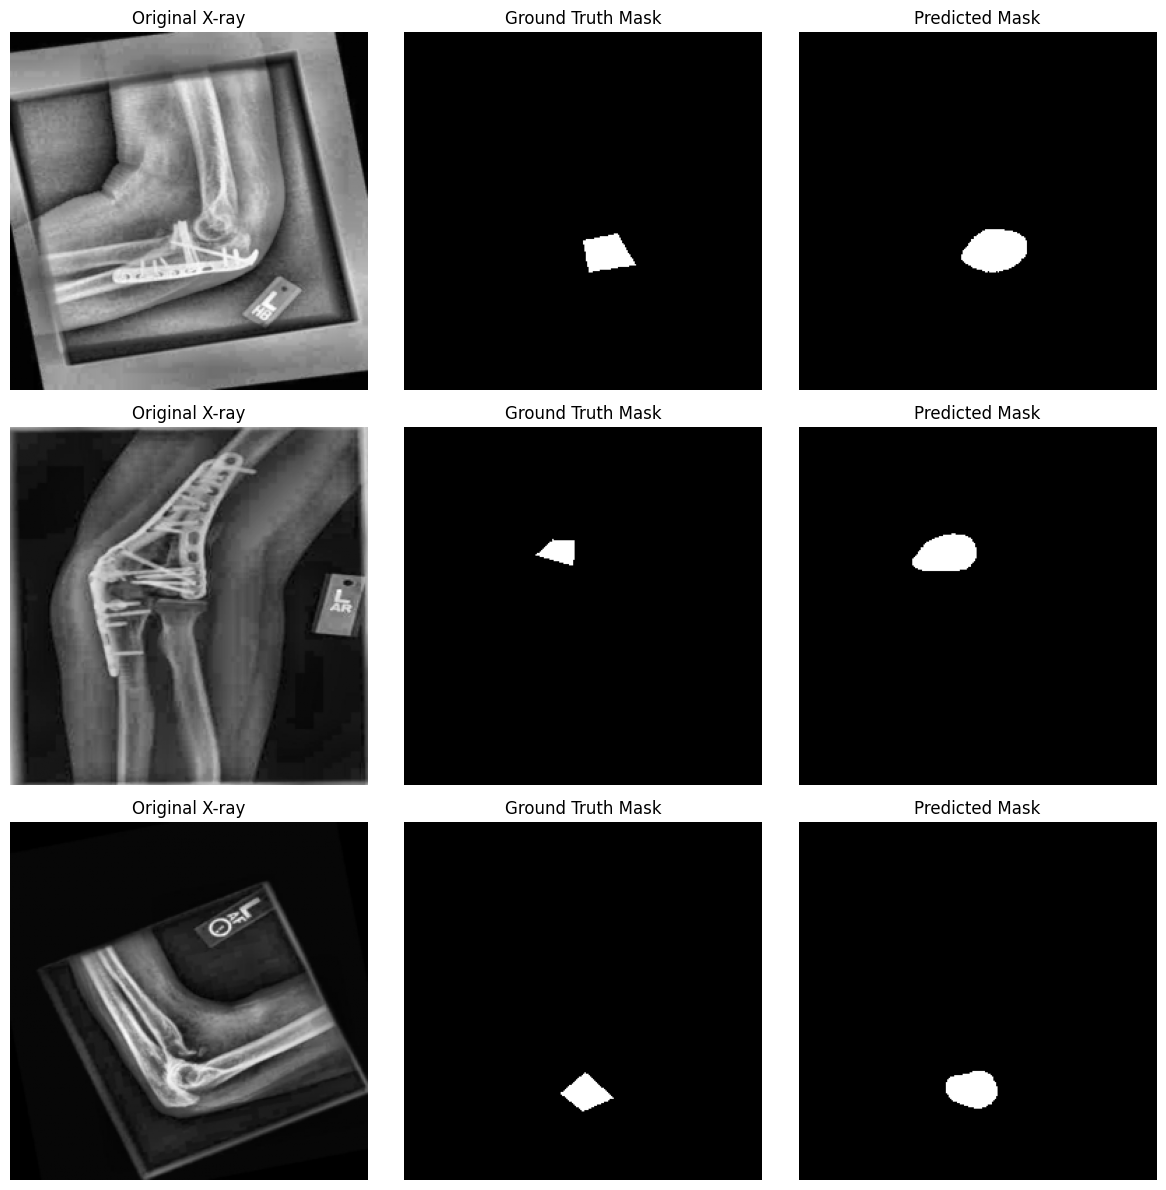

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Take one test batch
images, masks = next(iter(test_loader))

images_gpu = images.to(DEVICE)

# Prediction
with torch.no_grad():
    outputs = model(images_gpu)

probabilities = torch.sigmoid(outputs)
predictions = (probabilities > 0.5).float()

# Show 3 test examples
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):

    image = images[i][0].cpu().numpy()
    ground_truth = masks[i][0].cpu().numpy()
    prediction = predictions[i][0].cpu().numpy()

    # Original
    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title("Original X-ray")

    # Ground truth
    axes[i, 1].imshow(ground_truth, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")

    # Prediction
    axes[i, 2].imshow(prediction, cmap="gray")
    axes[i, 2].set_title("Predicted Mask")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import json

# Save training history
with open(
    "/content/training_history_10_epochs.json",
    "w"
) as f:
    json.dump(history, f, indent=4)

# Save final test results
test_results = {
    "test_loss": test_loss,
    "test_dice": test_dice,
    "test_iou": test_iou,
    "epochs": 10,
    "model": "U-Net",
    "encoder": "ResNet34",
    "encoder_weights": "ImageNet pretrained"
}

with open(
    "/content/test_results.json",
    "w"
) as f:
    json.dump(test_results, f, indent=4)

print("✅ Results saved")

✅ Results saved


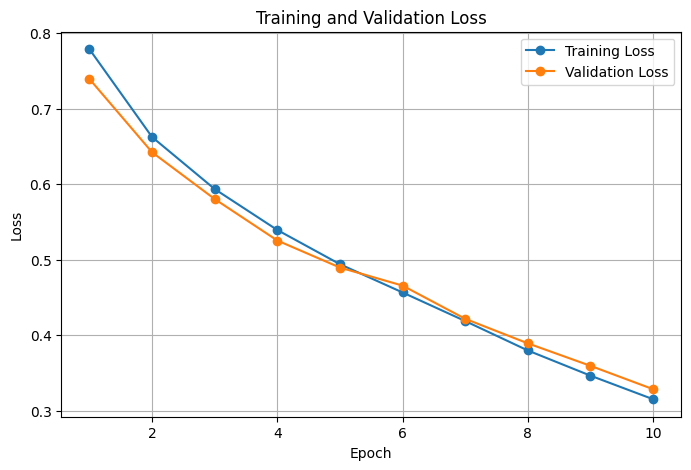

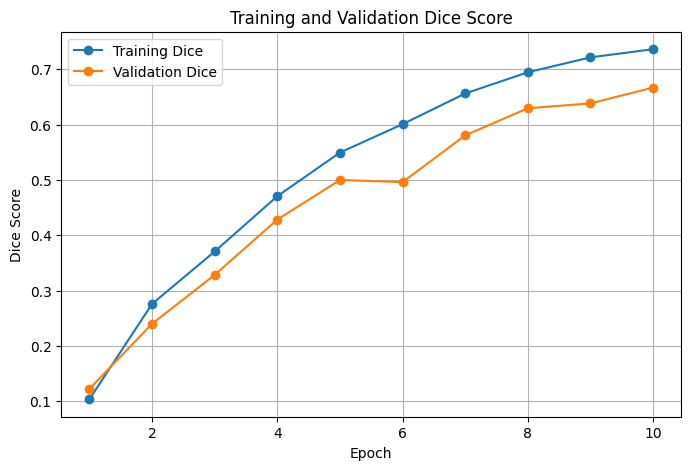

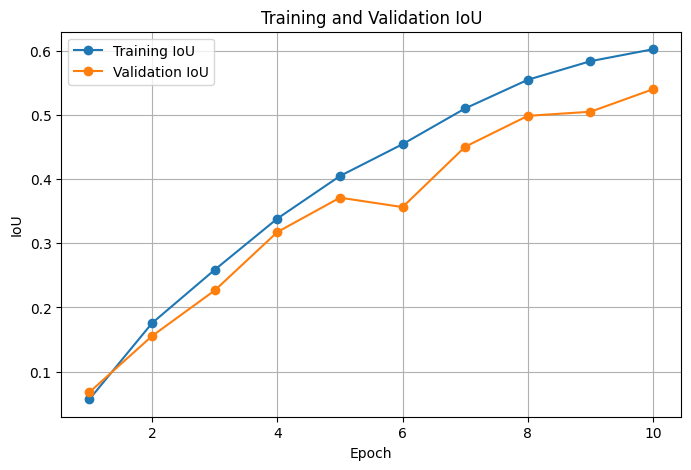

In [ ]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]

train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]

train_dice = [h["train_dice"] for h in history]
val_dice = [h["val_dice"] for h in history]

train_iou = [h["train_iou"] for h in history]
val_iou = [h["val_iou"] for h in history]


# -----------------------------
# 1. Loss curve
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss, marker="o", label="Training Loss")
plt.plot(epochs, val_loss, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()


# -----------------------------
# 2. Dice curve
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_dice, marker="o", label="Training Dice")
plt.plot(epochs, val_dice, marker="o", label="Validation Dice")

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training and Validation Dice Score")

plt.legend()
plt.grid(True)

plt.show()


# -----------------------------
# 3. IoU curve
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_iou, marker="o", label="Training IoU")
plt.plot(epochs, val_iou, marker="o", label="Validation IoU")

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training and Validation IoU")

plt.legend()
plt.grid(True)

plt.show()

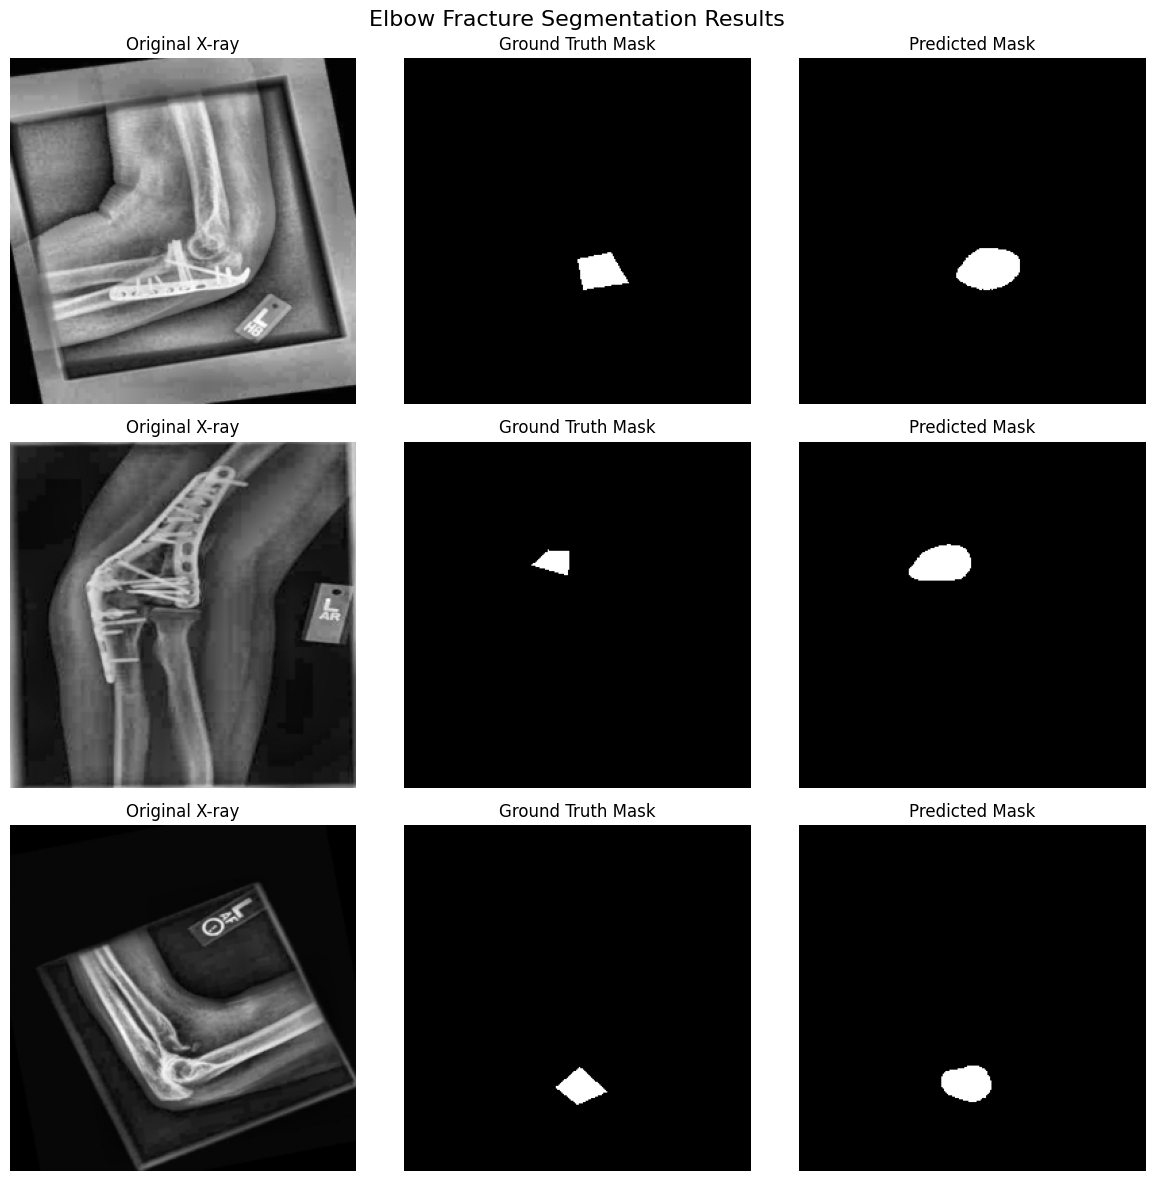

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ImageNet normalization values
mean = 0.485
std = 0.229

model.eval()

images, masks = next(iter(test_loader))
images_gpu = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images_gpu)

predictions = torch.sigmoid(outputs)
predictions = (predictions > 0.5).float()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):

    # Undo ImageNet normalization for visualization
    image = (
        images[i][0].numpy() * std
    ) + mean

    image = np.clip(image, 0, 1)

    ground_truth = masks[i][0].numpy()

    prediction = (
        predictions[i][0]
        .cpu()
        .numpy()
    )

    # Original
    axes[i, 0].imshow(
        image,
        cmap="gray"
    )
    axes[i, 0].set_title(
        "Original X-ray"
    )

    # Ground truth
    axes[i, 1].imshow(
        ground_truth,
        cmap="gray"
    )
    axes[i, 1].set_title(
        "Ground Truth Mask"
    )

    # Prediction
    axes[i, 2].imshow(
        prediction,
        cmap="gray"
    )
    axes[i, 2].set_title(
        "Predicted Mask"
    )

    for j in range(3):
        axes[i, j].axis("off")

plt.suptitle(
    "Elbow Fracture Segmentation Results",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "/content/final_prediction_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()